In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [4]:
df.shape

(6607, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df["Teacher_Quality"].unique()

array(['Medium', 'High', 'Low', nan], dtype=object)

In [8]:
df["Teacher_Quality"].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [9]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

In [10]:
df["Teacher_Quality"].isnull().sum()

np.int64(0)

In [11]:
df["Parental_Education_Level"].unique()

array(['High School', 'College', 'Postgraduate', nan], dtype=object)

In [13]:
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

In [60]:
df["Parental_Education_Level"].isnull().sum()

np.int64(0)

In [61]:
df["Distance_from_Home"].mode()

0    Near
Name: Distance_from_Home, dtype: object

In [14]:
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

In [63]:
df["Distance_from_Home"].isnull().sum()

np.int64(0)

In [64]:
import matplotlib.pyplot as plt

In [65]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

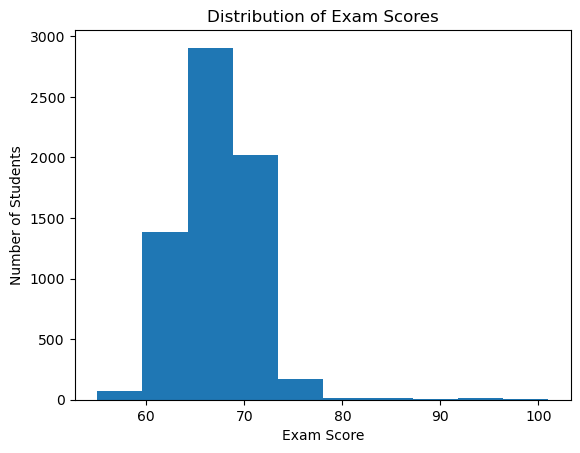

In [66]:
plt.hist(df["Exam_Score"])
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

In [67]:
df["Exam_Score"].max()

101

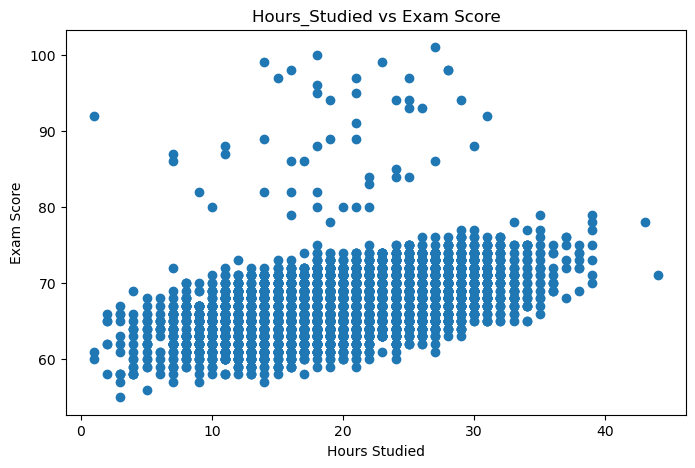

In [68]:
plt.figure(figsize=(8,5))

plt.scatter(df["Hours_Studied"], df["Exam_Score"])

plt.title("Hours_Studied vs Exam Score")

plt.xlabel("Hours Studied")

plt.ylabel("Exam Score")

plt.show()

In [69]:
numerical_df = df.select_dtypes(include=["int64", "float64"])
correlation= numerical_df.corr()
correlation

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


In [70]:
import seaborn as sns

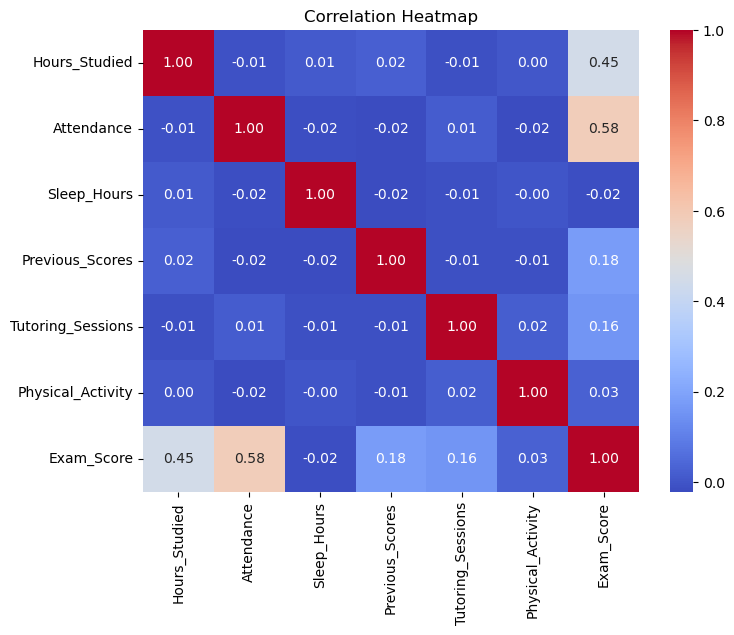

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")

plt.show()

In [72]:
df.select_dtypes(include="object").columns

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

In [73]:
from sklearn.preprocessing import LabelEncoder

In [74]:
label_encoder = LabelEncoder()

In [75]:
df["Gender"]= label_encoder.fit_transform(df["Gender"])

In [76]:
df["Gender"].head()

0    1
1    0
2    1
3    1
4    0
Name: Gender, dtype: int64

In [77]:
categorical_columns = df.select_dtypes(include="object").columns

In [78]:
for column in categorical_columns:
    df[column]= label_encoder.fit_transform(df[column])

In [79]:
X = df.drop("Exam_Score", axis=1)

In [80]:
y = df["Exam_Score"]

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42)

In [83]:
X_train.shape

(5285, 19)

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
model = LinearRegression()

In [86]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
predictions = model.predict(X_test)

In [88]:
predictions[:10]

array([65.21661267, 67.44841105, 69.82970337, 67.28780452, 66.75815888,
       68.12362991, 71.34655218, 67.88775689, 70.61053195, 69.73680481])

In [89]:
y_test.head(10)

743     65
5551    65
3442    71
6571    64
4204    66
2516    66
4047    72
1706    66
1075    70
233     70
Name: Exam_Score, dtype: int64

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [97]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error", mae)
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error", mse)
r2 = r2_score(y_test, predictions)
print("r2_score", r2)

Mean Absolute Error 1.0155490830845972
Mean Squared Error 4.399275539170955
r2_score 0.6887688020307756
